# Unified Transfer & Probing Audit

**Question:** Do ADNI-derived latent/connectomic representations carry
transferable information into the COVID cohort?

This notebook synthesises two **complementary but non-equivalent**
analyses performed on the same 194-subject COVID/CONTROL cohort.
Each analysis constitutes a different *lens* on the data; they do not
answer the same statistical question.

### Conceptual comparison of lenses

| Lens | Input features | Target learned during training | Score meaning | Main scientific use |
|------|---------------|-------------------------------|---------------|---------------------|
| **Transfer** (AD-likeness) | Connectivity matrices / latent μ | AD vs CN (ADNI cohort) | P(AD): how much a COVID subject's brain resembles AD | Biological / phenotypic projection — does COVID affect AD-relevant circuits? |
| **Probing** (supervised discrimination) | Frozen latent μ / metadata | COVID vs CONTROL (COVID cohort) | P(COVID): cross-validated COVID-status prediction | Classification utility — can ADNI-derived features separate COVID from CONTROL? |

> **Key distinction — different tasks, different targets.**
> Transfer scores measure *AD-likeness* (how similar a COVID subject's
> brain connectivity is to Alzheimer's disease).
> Probing scores measure *COVID separability* (whether the same latent
> features can classify COVID vs CONTROL).
> A representation **can carry biologically meaningful AD-related signal
> without being useful for COVID classification**, and vice-versa.
> Poor probing performance does **not** automatically invalidate
> transfer findings.

### Table of Contents
1. Setup & Path Validation
2. Cohort Harmonization
3. Transfer Summary — AD-Likeness Scores
4. Probing Summary — COVID Classification
5. Cross-Analysis Bridge (Subject-Level Scatter)
6. Group Separation Comparison
7. Why the Two Lenses Can Disagree
8. Mechanistic Bridge — Score Concordance
9. Transfer Score vs Clinical Correlate (MOCA)
10. Integrated Scientific Interpretation

## §1 — Setup & Path Validation

In [1]:
import warnings, logging
warnings.filterwarnings("ignore")
#logging.getLogger("matplotlib").setLevel(logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score
from scipy import stats
from matplotlib.lines import Line2D

from betavae_xai.analysis_qc.notebook_utils import (
    set_publication_style, save_figure,
)

set_publication_style("paper")
# Ensure inline display in Jupyter environments
%matplotlib inline
FIG_FORMATS = ["png", "pdf"]

# ── Paths ──────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

TRANSFER_DIR = PROJECT_ROOT / "results" / "vae_3channels_beta65_pro" / "transfer_v1_paper_output"
PROBING_DIR  = PROJECT_ROOT / "results" / "vae_3channels_beta65_pro" / "covid_classification_probing"
FIG_DIR      = (PROJECT_ROOT / "results" / "vae_3channels_beta65_pro"
                / "unified_transfer_probing_audit" / "Figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Load tables ────────────────────────────────────────────────────
transfer         = pd.read_csv(TRANSFER_DIR / "Tables" / "v1_merged_covid_scores_with_metadata.csv")
transfer_summary = pd.read_csv(TRANSFER_DIR / "Tables" / "v1_summary_three_variants.csv")
oof_fusion       = pd.read_csv(PROBING_DIR / "Tables" / "oof_predictions_late_fusion.csv")
probing_summary  = pd.read_csv(PROBING_DIR / "Tables" / "summary_late_fusion.csv")

for name, df in [("Transfer (merged)", transfer),
                 ("Transfer summary", transfer_summary),
                 ("Probing OOF (late fusion)", oof_fusion),
                 ("Probing summary", probing_summary)]:
    print(f"{name:35s} {df.shape}")

print(f"\nFigures will be saved to: {FIG_DIR}")

Transfer (merged)                   (194, 23)
Transfer summary                    (3, 8)
Probing OOF (late fusion)           (1164, 8)
Probing summary                     (6, 17)

Figures will be saved to: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/unified_transfer_probing_audit/Figures


## §2 — Cohort Harmonization

Both analyses consume the same 194-subject COVID/CONTROL cohort.
Below we verify perfect alignment at the subject-ID level.

In [2]:
transfer_ids = set(transfer["SubjectID"])
probing_ids  = set(oof_fusion["SubjectID"])

n_transfer  = len(transfer_ids)
n_probing   = len(probing_ids)
n_overlap   = len(transfer_ids & probing_ids)

print(f"Transfer subjects : {n_transfer}")
print(f"Probing subjects  : {n_probing}")
print(f"Intersection      : {n_overlap}")
print(f"Only in transfer  : {len(transfer_ids - probing_ids)}")
print(f"Only in probing   : {len(probing_ids - transfer_ids)}")

assert n_overlap == n_transfer == n_probing == 194, (
    f"Subject mismatch — expected 194 in both analyses, "
    f"got transfer={n_transfer}, probing={n_probing}, overlap={n_overlap}"
)
print("\n✓ Perfect alignment: 194 subjects present in both analyses.")

grupo_counts = transfer.groupby("Grupo").size()
prevalence   = grupo_counts["COVID"] / len(transfer)
print(f"\nCOVID  : {grupo_counts['COVID']}  ({prevalence:.1%})")
print(f"CONTROL: {grupo_counts['CONTROL']}  ({1 - prevalence:.1%})")
print(f"\nNote: PR-AUC baseline for a random classifier ≈ {prevalence:.3f}")

Transfer subjects : 194
Probing subjects  : 194
Intersection      : 194
Only in transfer  : 0
Only in probing   : 0

✓ Perfect alignment: 194 subjects present in both analyses.

COVID  : 151  (77.8%)
CONTROL: 43  (22.2%)

Note: PR-AUC baseline for a random classifier ≈ 0.778


## §3 — Transfer Summary: AD-Likeness Projection

The transfer analysis projects three ADNI-trained classifiers onto the
COVID cohort.  Each produces an **AD-likeness score** ∈ [0, 1] — a
*phenotypic projection*, not a COVID classifier.

| Variant | Description |
|---------|-------------|
| **V1-A** | Logistic regression on raw connectivity edges |
| **V1-B** | Logistic regression on frozen β-VAE encoder (μ) |
| **V1-C** | Logistic regression on domain-adapted β-VAE encoder (μ) |

The Youden threshold (dashed line) was derived from ADNI validation
to optimally separate AD from CN.

> **Interpretation note:** a Grupo ROC-AUC ≈ 0.5 means COVID and
> CONTROL subjects are *equally* distributed along the AD-likeness
> axis.  This does **not** mean the projection is uninformative — it
> means COVID status is not aligned with the AD phenotype gradient.

Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/unified_transfer_probing_audit/Figures/fig1_transfer_score_distributions.png
Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/unified_transfer_probing_audit/Figures/fig1_transfer_score_distributions.pdf


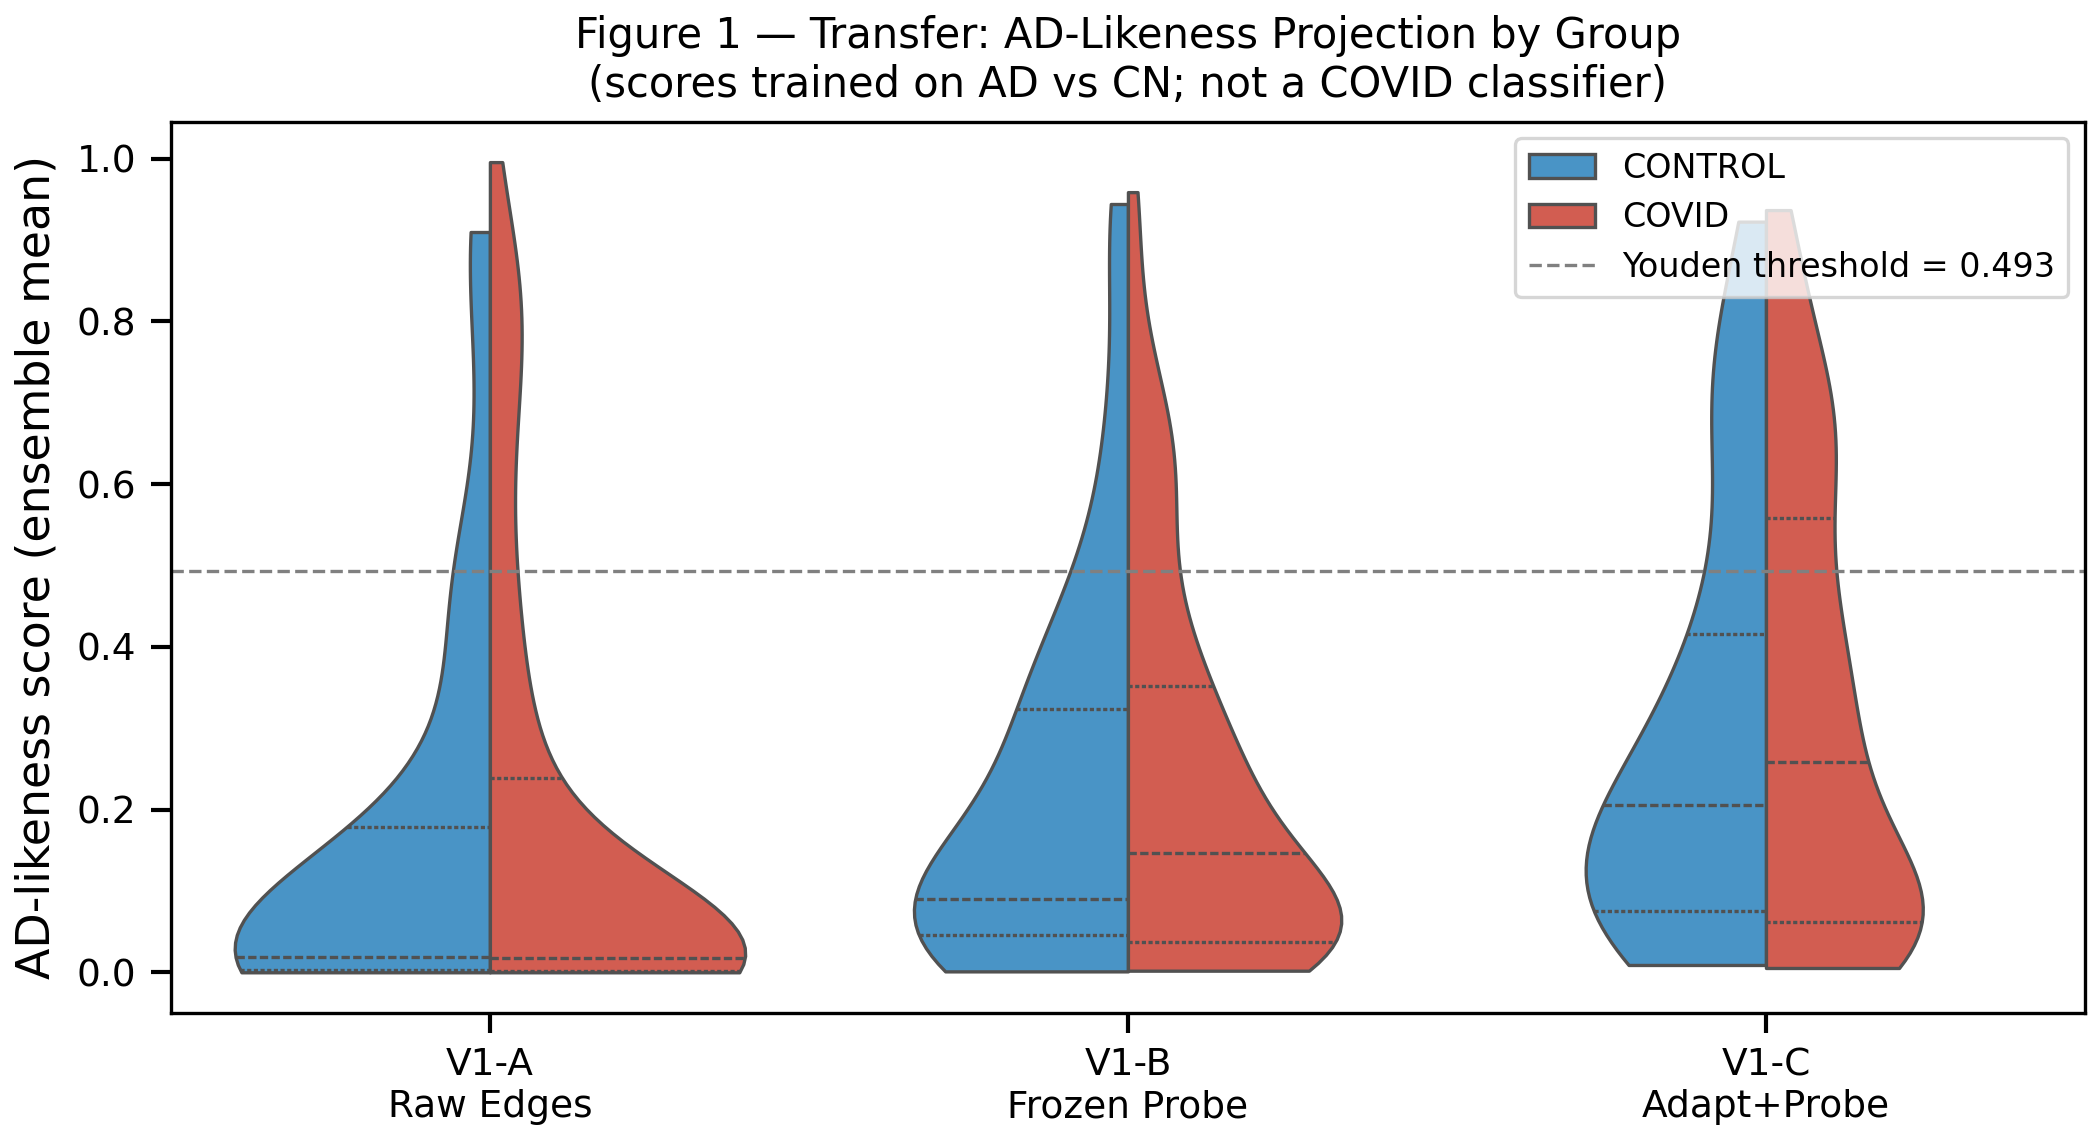

In [3]:
# ── Shared palettes ────────────────────────────────────────────────
GRUPO_PALETTE = {"COVID": "#e74c3c", "CONTROL": "#3498db"}
VARIANT_MAP   = {
    "v1a_y_score_mean": "V1-A\nRaw Edges",
    "v1b_y_score_mean": "V1-B\nFrozen Probe",
    "v1c_y_score_mean": "V1-C\nAdapt+Probe",
}
VARIANT_LABELS_FLAT = {k: v.replace("\n", " ") for k, v in VARIANT_MAP.items()}
score_cols = list(VARIANT_MAP.keys())

# Long-form for violin
df_long = transfer.melt(
    id_vars=["SubjectID", "Grupo"],
    value_vars=score_cols,
    var_name="variant_col",
    value_name="AD-likeness score",
)
df_long["Variant"] = df_long["variant_col"].map(VARIANT_MAP)

fig, ax = plt.subplots(figsize=(7.2, 4.0))
sns.violinplot(
    data=df_long, x="Variant", y="AD-likeness score",
    hue="Grupo", split=True, inner="quart",
    palette=GRUPO_PALETTE, ax=ax, cut=0, linewidth=0.8,
)
youden = transfer_summary["youden_threshold"].iloc[0]
ax.axhline(youden, ls="--", lw=0.8, color="gray",
           label=f"Youden threshold = {youden:.3f}")
ax.set_xlabel("")
ax.set_ylabel("AD-likeness score (ensemble mean)")
ax.set_title("Figure 1 — Transfer: AD-Likeness Projection by Group\n(scores trained on AD vs CN; not a COVID classifier)", fontsize=10)
ax.legend(loc="upper right", frameon=True, fontsize=8)
fig.tight_layout()
save_figure(fig, FIG_DIR / "fig1_transfer_score_distributions", formats=FIG_FORMATS)
plt.show()

In [4]:
# Compute ROC-AUC for Grupo discrimination (COVID=1, CONTROL=0)
y_grupo = (transfer["Grupo"] == "COVID").astype(int).values

grupo_aucs = {
    VARIANT_LABELS_FLAT[c]: roc_auc_score(y_grupo, transfer[c].values)
    for c in score_cols
}

ts = transfer_summary.copy()
ts["Grupo ROC-AUC"] = [grupo_aucs[VARIANT_LABELS_FLAT[c]] for c in score_cols]

display(
    ts.rename(columns={
        "variant":              "Variant",
        "adni_mean_auc":        "ADNI AUC (AD vs CN)",
        "adni_std_auc":         "ADNI AUC std",
        "covid_mean_score_mean": "Mean AD-likeness (all)",
        "pct_covid_above_youden": "% Above Youden",
    })[["Variant", "ADNI AUC (AD vs CN)", "ADNI AUC std",
        "Mean AD-likeness (all)", "% Above Youden", "Grupo ROC-AUC"]]
    .style.format({
        "ADNI AUC (AD vs CN)": "{:.3f}",
        "ADNI AUC std":        "{:.3f}",
        "Mean AD-likeness (all)": "{:.3f}",
        "% Above Youden":      "{:.1%}",
        "Grupo ROC-AUC":       "{:.3f}",
    })
    .set_caption("Table 1 — Transfer variants: ADNI performance and COVID-cohort group discrimination")
)

print("\nNote: Grupo ROC-AUC is computed on the full 194-subject sample (no CV).")
print("A value ≈ 0.5 means COVID and CONTROL subjects are spread equally along the AD-likeness axis.")
print("This is a *descriptive* measure of group overlap on a foreign task — not a COVID classification metric.")

,Variant,ADNI AUC (AD vs CN),ADNI AUC std,Mean AD-likeness (all),% Above Youden,Grupo ROC-AUC
0,V1-A,0.807,0.056,0.167,13.4%,0.499
1,V1-B,0.776,0.049,0.229,14.9%,0.506
2,V1-C,0.761,0.062,0.314,27.3%,0.505



Note: Grupo ROC-AUC is computed on the full 194-subject sample (no CV).
A value ≈ 0.5 means COVID and CONTROL subjects are spread equally along the AD-likeness axis.
This is a *descriptive* measure of group overlap on a foreign task — not a COVID classification metric.


## §4 — Probing Summary: COVID vs CONTROL Classification

The probing analysis trains classifiers **on the COVID cohort** using features
extracted from frozen ADNI encoders, then evaluates via stratified 5-fold CV.

Three feature families:
- **Latent only:** β-VAE encoder μ (256-d)
- **Latent + metadata:** μ + Age + Sex
- **Metadata only:** Age + Sex (baseline)

Two classifiers: Logistic Regression and SVM.

Late fusion averages predictions across 5 ADNI encoder folds.

Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/unified_transfer_probing_audit/Figures/fig2_probing_auc_summary.png
Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/unified_transfer_probing_audit/Figures/fig2_probing_auc_summary.pdf


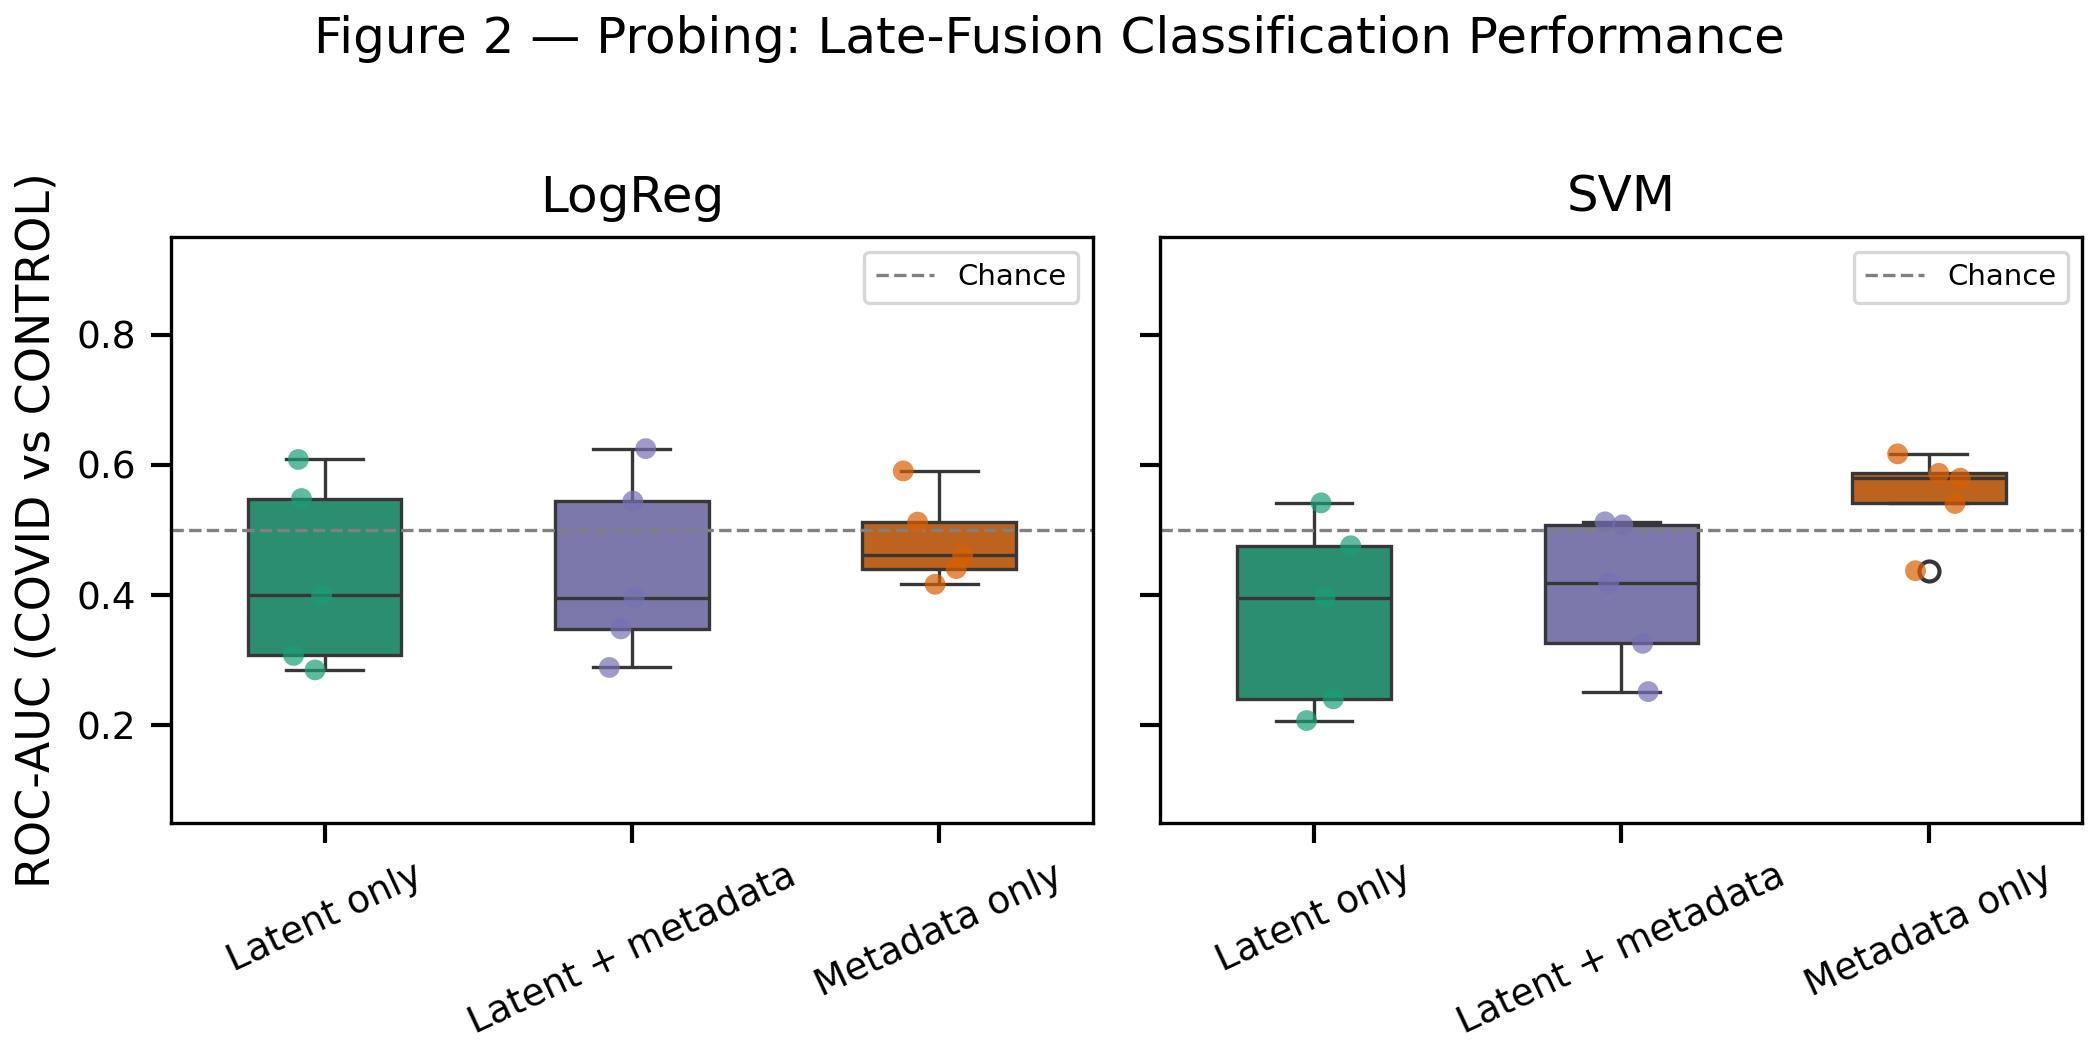

In [5]:
FAMILY_PALETTE = {
    "latent_only":          "#1b9e77",
    "latent_plus_metadata": "#7570b3",
    "metadata_only":        "#d95f02",
}
FAMILY_LABELS = {
    "latent_only":          "Latent only",
    "latent_plus_metadata": "Latent + metadata",
    "metadata_only":        "Metadata only",
}
CLF_LABELS = {"logreg": "LogReg", "svm": "SVM"}
LABEL_PALETTE = {FAMILY_LABELS[k]: v for k, v in FAMILY_PALETTE.items()}

# Per-fold AUC from OOF predictions
fold_aucs = []
for (mt, ff, fold), grp in oof_fusion.groupby(
        ["model_type", "feature_family", "covid_outer_fold"]):
    auc = roc_auc_score(grp["y_true"], grp["y_score_fused"])
    fold_aucs.append(dict(model_type=mt, feature_family=ff, fold=fold, auc=auc))
fold_aucs = pd.DataFrame(fold_aucs)
fold_aucs["family_label"] = fold_aucs["feature_family"].map(FAMILY_LABELS)
fold_aucs["clf_label"]    = fold_aucs["model_type"].map(CLF_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.5), sharey=True)
for i, clf in enumerate(["LogReg", "SVM"]):
    ax  = axes[i]
    sub = fold_aucs[fold_aucs["clf_label"] == clf]
    sns.boxplot(data=sub, x="family_label", y="auc",
                palette=LABEL_PALETTE, ax=ax, width=0.5, linewidth=0.8)
    sns.stripplot(data=sub, x="family_label", y="auc",
                  palette=LABEL_PALETTE, ax=ax, size=5, alpha=0.7, jitter=0.12)
    ax.axhline(0.5, ls="--", lw=0.8, color="gray", label="Chance")
    ax.set_title(clf)
    ax.set_xlabel("")
    ax.set_ylim(0.05, 0.95)
    if i == 0:
        ax.set_ylabel("ROC-AUC (COVID vs CONTROL)")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(loc="upper right", fontsize=7)
fig.suptitle("Figure 2 — Probing: Late-Fusion Classification Performance", y=1.02)
fig.tight_layout()
save_figure(fig, FIG_DIR / "fig2_probing_auc_summary", formats=FIG_FORMATS)
plt.show()

In [6]:
ps = probing_summary.copy()
ps["Classifier"]     = ps["model_type"].map(CLF_LABELS)
ps["Feature family"]  = ps["feature_family"].map(FAMILY_LABELS)
ps["AUC"]            = ps.apply(lambda r: f"{r.auc_mean:.3f} ± {r.auc_std:.3f}", axis=1)
ps["Bal. Accuracy"]  = ps.apply(lambda r: f"{r.balanced_accuracy_mean:.3f} ± {r.balanced_accuracy_std:.3f}", axis=1)
ps["PR-AUC"]         = ps.apply(lambda r: f"{r.pr_auc_mean:.3f} ± {r.pr_auc_std:.3f}", axis=1)

display(
    ps[["Classifier", "Feature family", "AUC", "Bal. Accuracy", "PR-AUC"]]
    .style.set_caption("Table 2 — Probing: Late-fusion metrics (mean ± std, 5-fold COVID CV)")
)

print("\nAll probing AUCs are at or below chance (0.5).")
print("PR-AUC baseline ≈ 0.778 (prevalence); all PR-AUC values are near/below baseline.")
print("→ Frozen ADNI encoder features do not support supervised COVID vs CONTROL discrimination.")
print("  (This does not imply the latent space is biologically uninformative — see §7.)")

,Classifier,Feature family,AUC,Bal. Accuracy,PR-AUC
0,LogReg,Latent only,0.430 ± 0.144,0.449 ± 0.095,0.761 ± 0.074
1,LogReg,Latent + metadata,0.441 ± 0.140,0.459 ± 0.096,0.767 ± 0.071
2,LogReg,Metadata only,0.484 ± 0.069,0.573 ± 0.065,0.759 ± 0.045
3,SVM,Latent only,0.372 ± 0.145,0.491 ± 0.020,0.735 ± 0.080
4,SVM,Latent + metadata,0.403 ± 0.114,0.504 ± 0.010,0.749 ± 0.077
5,SVM,Metadata only,0.552 ± 0.070,0.558 ± 0.066,0.819 ± 0.049



All probing AUCs are at or below chance (0.5).
PR-AUC baseline ≈ 0.778 (prevalence); all PR-AUC values are near/below baseline.
→ Frozen ADNI encoder features do not support supervised COVID vs CONTROL discrimination.
  (This does not imply the latent space is biologically uninformative — see §7.)


## §5 — Cross-Analysis Bridge: Subject-Level Scatter

**Key comparison pair:**
- **Transfer V1-B** (frozen encoder probe): P(AD) from LogReg on latent μ,
  trained on ADNI, applied to COVID subjects.
- **Probing LogReg latent_only**: P(COVID) from LogReg on latent μ,
  cross-validated within the COVID cohort.

Both use the same frozen encoder and the same classifier family, differing
only in **target label** (AD vs CN for transfer; COVID vs CONTROL for probing).

> **Caution:** These scores come from **different tasks** and are not
> directly commensurable.  The scatter below is *descriptive*: it shows
> whether subjects who look more AD-like also tend to be classified as
> COVID.  A weak correlation is expected if the two targets are
> biologically decoupled.

Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/unified_transfer_probing_audit/Figures/fig3_bridge_scatter.png
Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/unified_transfer_probing_audit/Figures/fig3_bridge_scatter.pdf


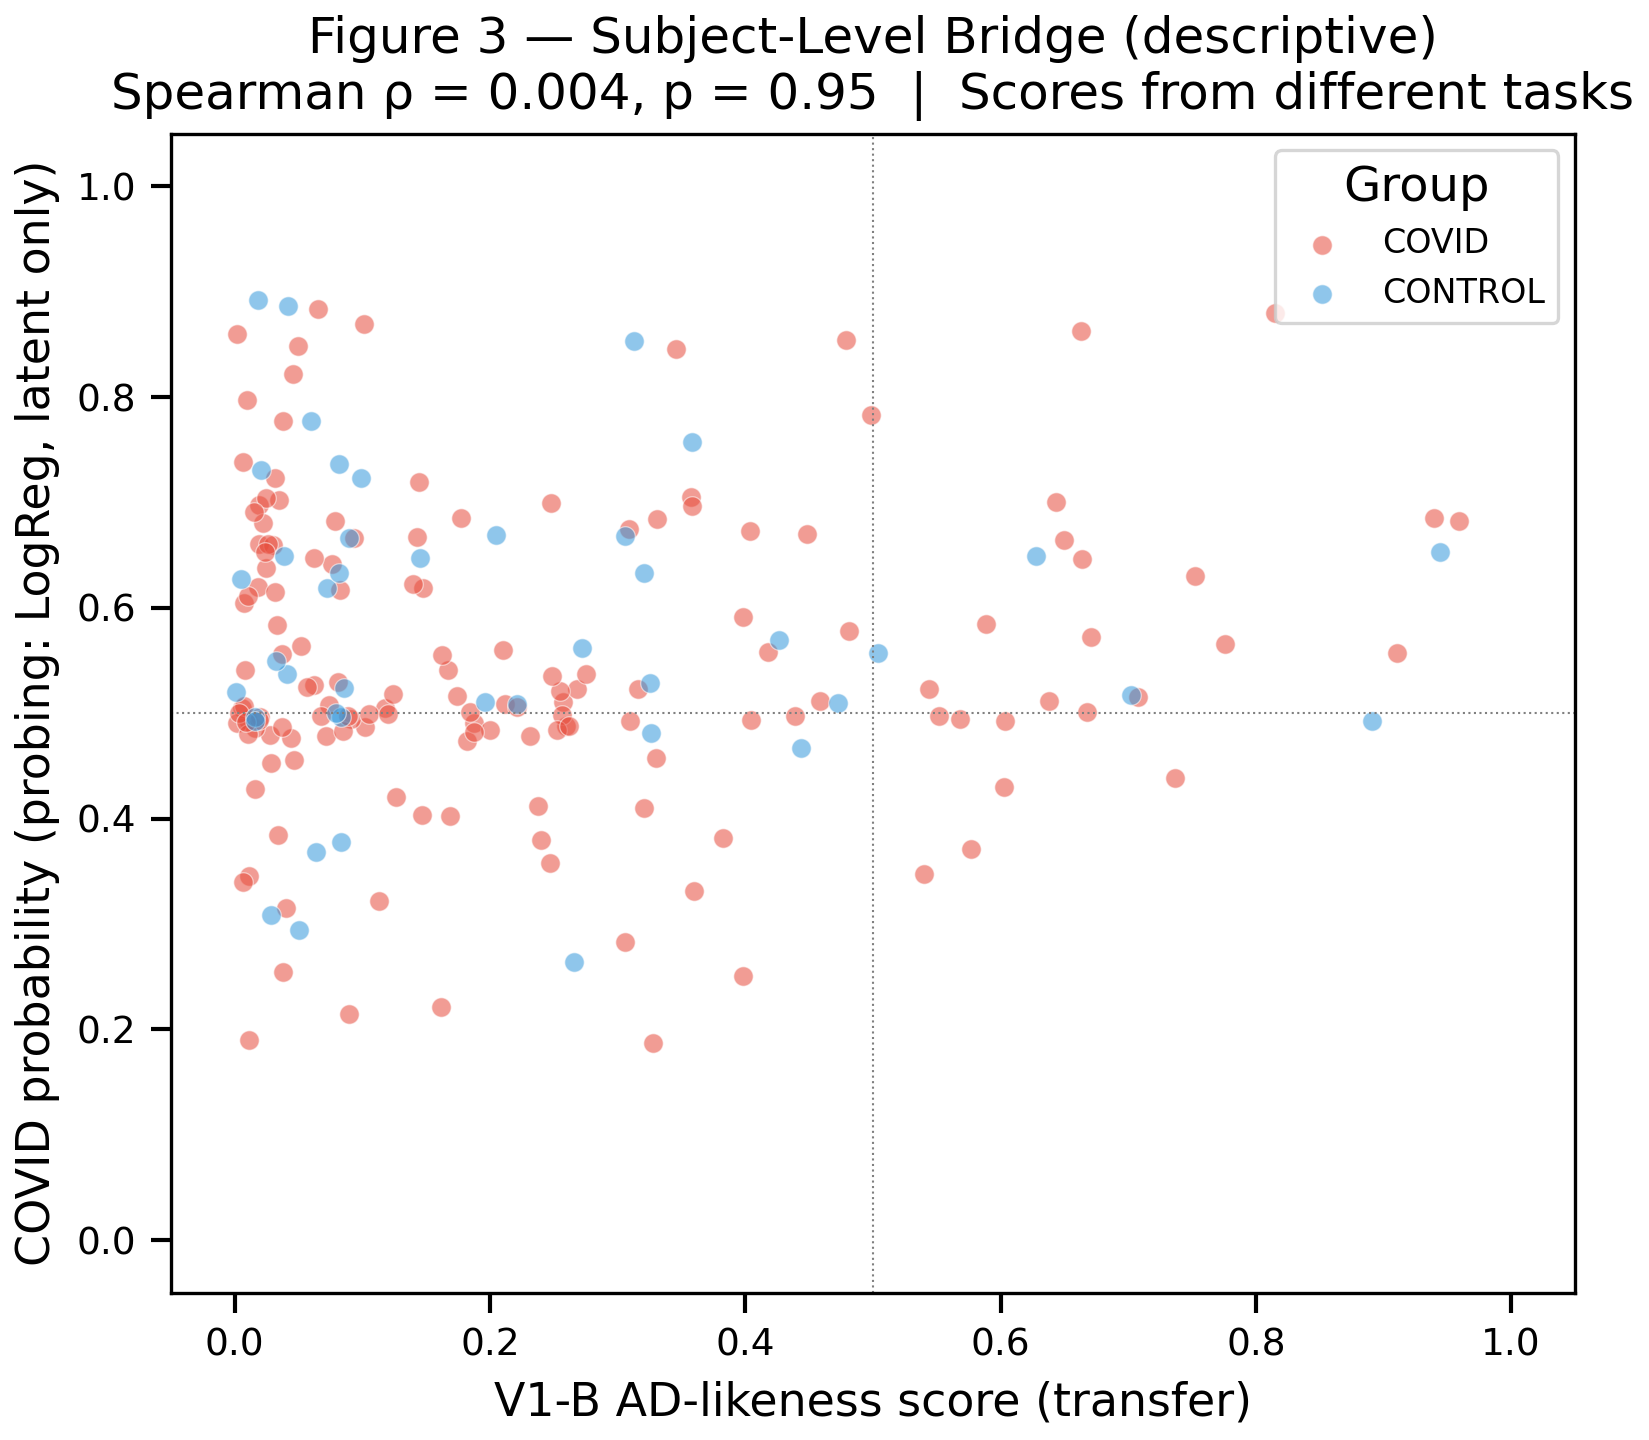

Spearman ρ = 0.0041  (p = 0.9543)
N subjects  = 194


In [7]:
# Per-subject probing score: LogReg × latent_only
probe_latent = oof_fusion.query(
    "model_type == 'logreg' and feature_family == 'latent_only'"
)[["SubjectID", "y_true", "y_score_fused"]].rename(
    columns={"y_score_fused": "probing_score"}
)

bridge = transfer[["SubjectID", "Grupo", "v1b_y_score_mean"]].merge(
    probe_latent, on="SubjectID", how="inner"
).rename(columns={"v1b_y_score_mean": "transfer_score"})

r_s, p_s = stats.spearmanr(bridge["transfer_score"], bridge["probing_score"])

fig, ax = plt.subplots(figsize=(5.5, 5.0))
for grupo, color in GRUPO_PALETTE.items():
    mask = bridge["Grupo"] == grupo
    ax.scatter(
        bridge.loc[mask, "transfer_score"],
        bridge.loc[mask, "probing_score"],
        c=color, label=grupo, alpha=0.55, s=22,
        edgecolors="white", linewidths=0.3,
    )
ax.axhline(0.5, ls=":", lw=0.5, color="gray")
ax.axvline(0.5, ls=":", lw=0.5, color="gray")
ax.set_xlabel("V1-B AD-likeness score (transfer)")
ax.set_ylabel("COVID probability (probing: LogReg, latent only)")
ax.set_title(
    f"Figure 3 — Subject-Level Bridge (descriptive)\n"
    f"Spearman ρ = {r_s:.3f}, p = {p_s:.2g}  |  Scores from different tasks"
)
ax.legend(title="Group", frameon=True, fontsize=8)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
fig.tight_layout()
save_figure(fig, FIG_DIR / "fig3_bridge_scatter", formats=FIG_FORMATS)
plt.show()

print(f"Spearman ρ = {r_s:.4f}  (p = {p_s:.4g})")
print(f"N subjects  = {len(bridge)}")

## §6 — Group Separation Comparison

Side-by-side comparison of how well each method's output discriminates
COVID from CONTROL.

- **Transfer AUC** — ROC-AUC of using the AD-likeness score to
  predict Grupo (computed on the full 194-subject sample, no CV).
- **Probing AUC** — cross-validated ROC-AUC (5-fold, mean ± std)
  of classifying COVID vs CONTROL from latent or metadata features.

> **Important:** The two AUCs measure different things.  Transfer AUC
> asks "does AD-likeness accidentally correlate with COVID status?"
> Probing AUC asks "can latent features predict COVID status when
> explicitly trained to do so?"  Direct numerical comparison between
> them is descriptive only — they address non-equivalent questions.

> Transfer AUC is not cross-validated (all 194 subjects scored in a
> single pass), so it is structurally more optimistic than probing
> CV AUC.

Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/unified_transfer_probing_audit/Figures/fig4_group_separation_comparison.png
Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/unified_transfer_probing_audit/Figures/fig4_group_separation_comparison.pdf


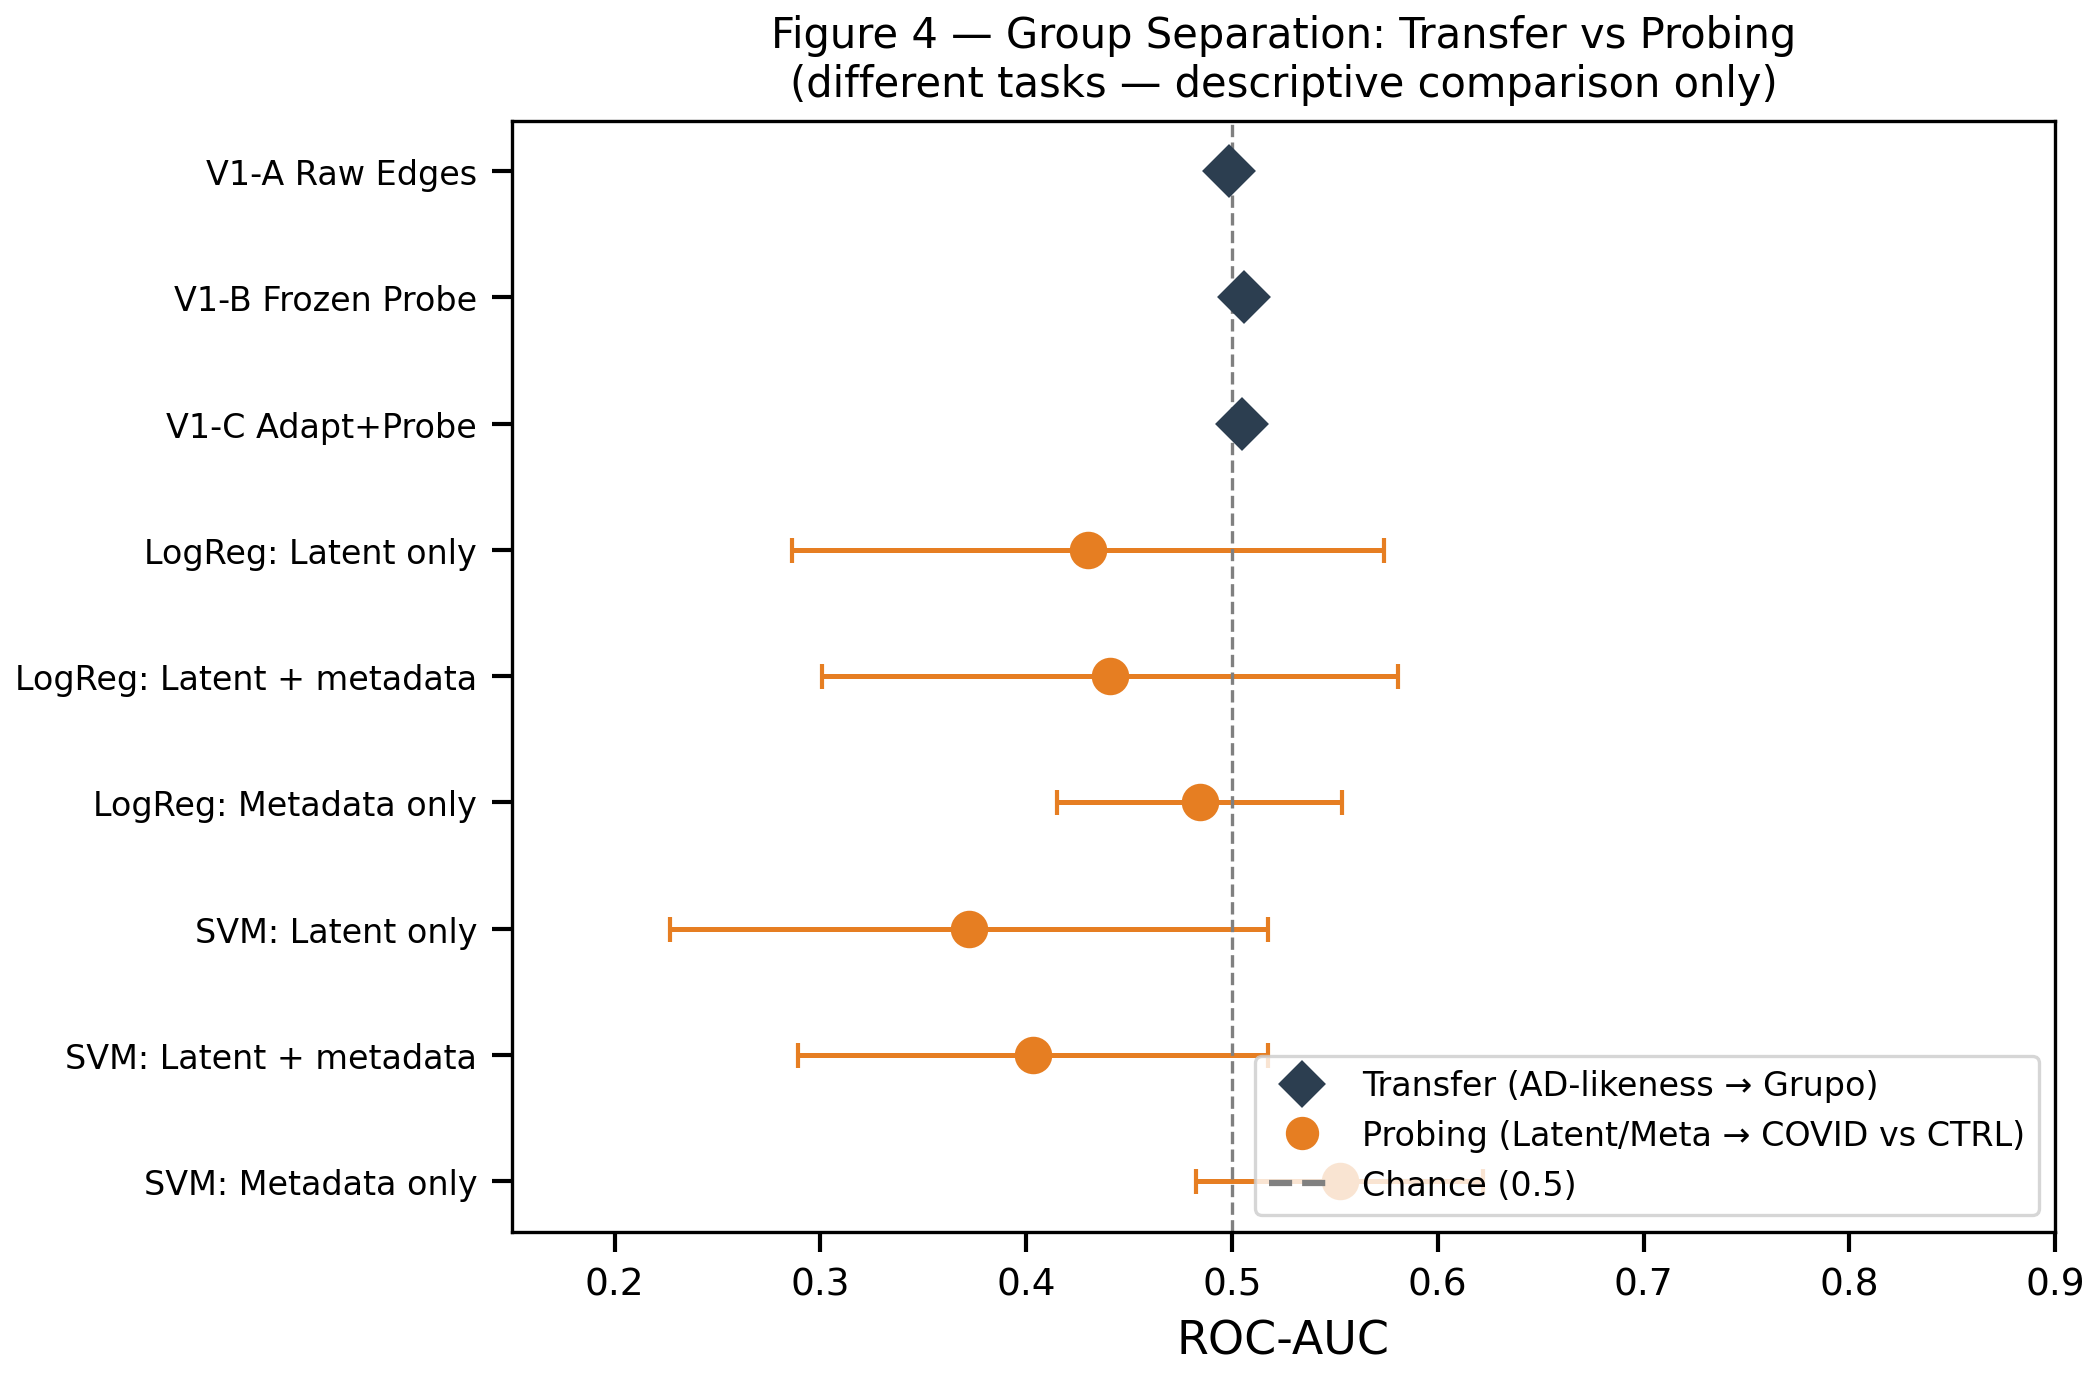

,Analysis,Method,AUC,AUC_std
0,Transfer,V1-A Raw Edges,0.499,nan
1,Transfer,V1-B Frozen Probe,0.506,nan
2,Transfer,V1-C Adapt+Probe,0.505,nan
3,Probing,LogReg: Latent only,0.430,0.144
4,Probing,LogReg: Latent + metadata,0.441,0.140
5,Probing,LogReg: Metadata only,0.484,0.069
6,Probing,SVM: Latent only,0.372,0.145
7,Probing,SVM: Latent + metadata,0.403,0.114
8,Probing,SVM: Metadata only,0.552,0.070


In [8]:
# Build comparison rows
rows = []
for c in score_cols:
    label = VARIANT_LABELS_FLAT[c]
    auc   = grupo_aucs[label]
    rows.append(dict(Analysis="Transfer", Method=label, AUC=auc, AUC_std=np.nan))

for _, r in probing_summary.iterrows():
    mt = CLF_LABELS[r["model_type"]]
    ff = FAMILY_LABELS[r["feature_family"]]
    rows.append(dict(Analysis="Probing", Method=f"{mt}: {ff}",
                     AUC=r["auc_mean"], AUC_std=r["auc_std"]))

comp = pd.DataFrame(rows)
y_pos = list(range(len(comp)))[::-1]

ANALYSIS_COLOR = {"Transfer": "#2c3e50", "Probing": "#e67e22"}

fig, ax = plt.subplots(figsize=(7.2, 4.8))
for i, (_, row) in enumerate(comp.iterrows()):
    y     = y_pos[i]
    color = ANALYSIS_COLOR[row["Analysis"]]
    marker = "D" if row["Analysis"] == "Transfer" else "o"
    ax.plot(row["AUC"], y, marker=marker, color=color, markersize=8, zorder=3)
    if not np.isnan(row["AUC_std"]):
        ax.errorbar(row["AUC"], y, xerr=row["AUC_std"],
                    color=color, capsize=3, lw=1.2, zorder=2)

ax.set_yticks(y_pos)
ax.set_yticklabels(comp["Method"], fontsize=8)
ax.axvline(0.5, ls="--", lw=0.8, color="gray")
ax.set_xlabel("ROC-AUC")
ax.set_title("Figure 4 — Group Separation: Transfer vs Probing\n(different tasks — descriptive comparison only)", fontsize=10)
ax.set_xlim(0.15, 0.90)

handles = [
    Line2D([], [], marker="D", ls="", color=ANALYSIS_COLOR["Transfer"],
           markersize=7, label="Transfer (AD-likeness → Grupo)"),
    Line2D([], [], marker="o", ls="", color=ANALYSIS_COLOR["Probing"],
           markersize=7, label="Probing (Latent/Meta → COVID vs CTRL)"),
    Line2D([], [], ls="--", color="gray", label="Chance (0.5)"),
]
ax.legend(handles=handles, loc="lower right", fontsize=8, frameon=True)
fig.tight_layout()
save_figure(fig, FIG_DIR / "fig4_group_separation_comparison", formats=FIG_FORMATS)
plt.show()

# Display the comparison table
display(comp.style.format({"AUC": "{:.3f}", "AUC_std": "{:.3f}"})
        .set_caption("Table 3 — Group separation AUCs"))

## §7 — Why the Two Lenses Can Disagree

Transfer and probing scores can legitimately disagree — or both show
weak effects for different reasons — without contradiction.  Four
structural factors explain this:

### 7.1 Task mismatch
Transfer scores reflect an **AD vs CN discriminant axis** learned on
an entirely different cohort (ADNI).  This axis captures Alzheimer's-
related connectivity signatures.  The probing task (COVID vs CONTROL)
is a different binary split that may not align with the AD axis at all.
A biologically meaningful AD-likeness gradient can exist in the COVID
cohort without producing strong COVID-vs-CONTROL classification.

### 7.2 Domain mismatch
The β-VAE encoder was trained on ADNI scans (elderly, neurodegenerative).
The COVID cohort is younger and healthy/post-COVID.  Domain shift in
data distributions means the encoder operates in a partially
out-of-distribution regime, limiting both transfer fidelity and probing
discriminability.

### 7.3 Phenotype vs binary label mismatch
AD-likeness is a **continuous phenotypic projection**.  COVID vs CONTROL
is a **binary label** that lumps heterogeneous clinical presentations
(mild vs severe, recovered vs symptomatic) into one group.  Subtle
clinical gradients (e.g., cognitive burden indexed by MOCA) may track
the AD-likeness axis even if the coarse binary label does not.

### 7.4 High-dimensional / small-sample probing
With n = 194 subjects and 256-dimensional latent features, probing
classifiers operate in a high-d / low-n regime vulnerable to
overfitting and noise.  A weak distributed signal present in the
latent space can fail to produce above-chance classification simply
because the effect size per feature is below the detection threshold
of logistic regression / SVM with this sample size.

## §8 — Mechanistic Bridge: Score Concordance Heatmap

Do the transfer and probing scores agree at the subject level?
We compute **Spearman ρ** between every (transfer variant, probing model)
pair across all 194 subjects.

A strong positive ρ would indicate that subjects who look more AD-like
also tend to be classified as COVID.  A value near zero indicates that
the two score axes capture different variance — consistent with the
task mismatch described in §7.

> **Reminder:** correlation between scores from different tasks is
> descriptive, not inferential.  These scores have different targets,
> units, and training regimes.

Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/unified_transfer_probing_audit/Figures/fig5_concordance_heatmap.png
Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/unified_transfer_probing_audit/Figures/fig5_concordance_heatmap.pdf


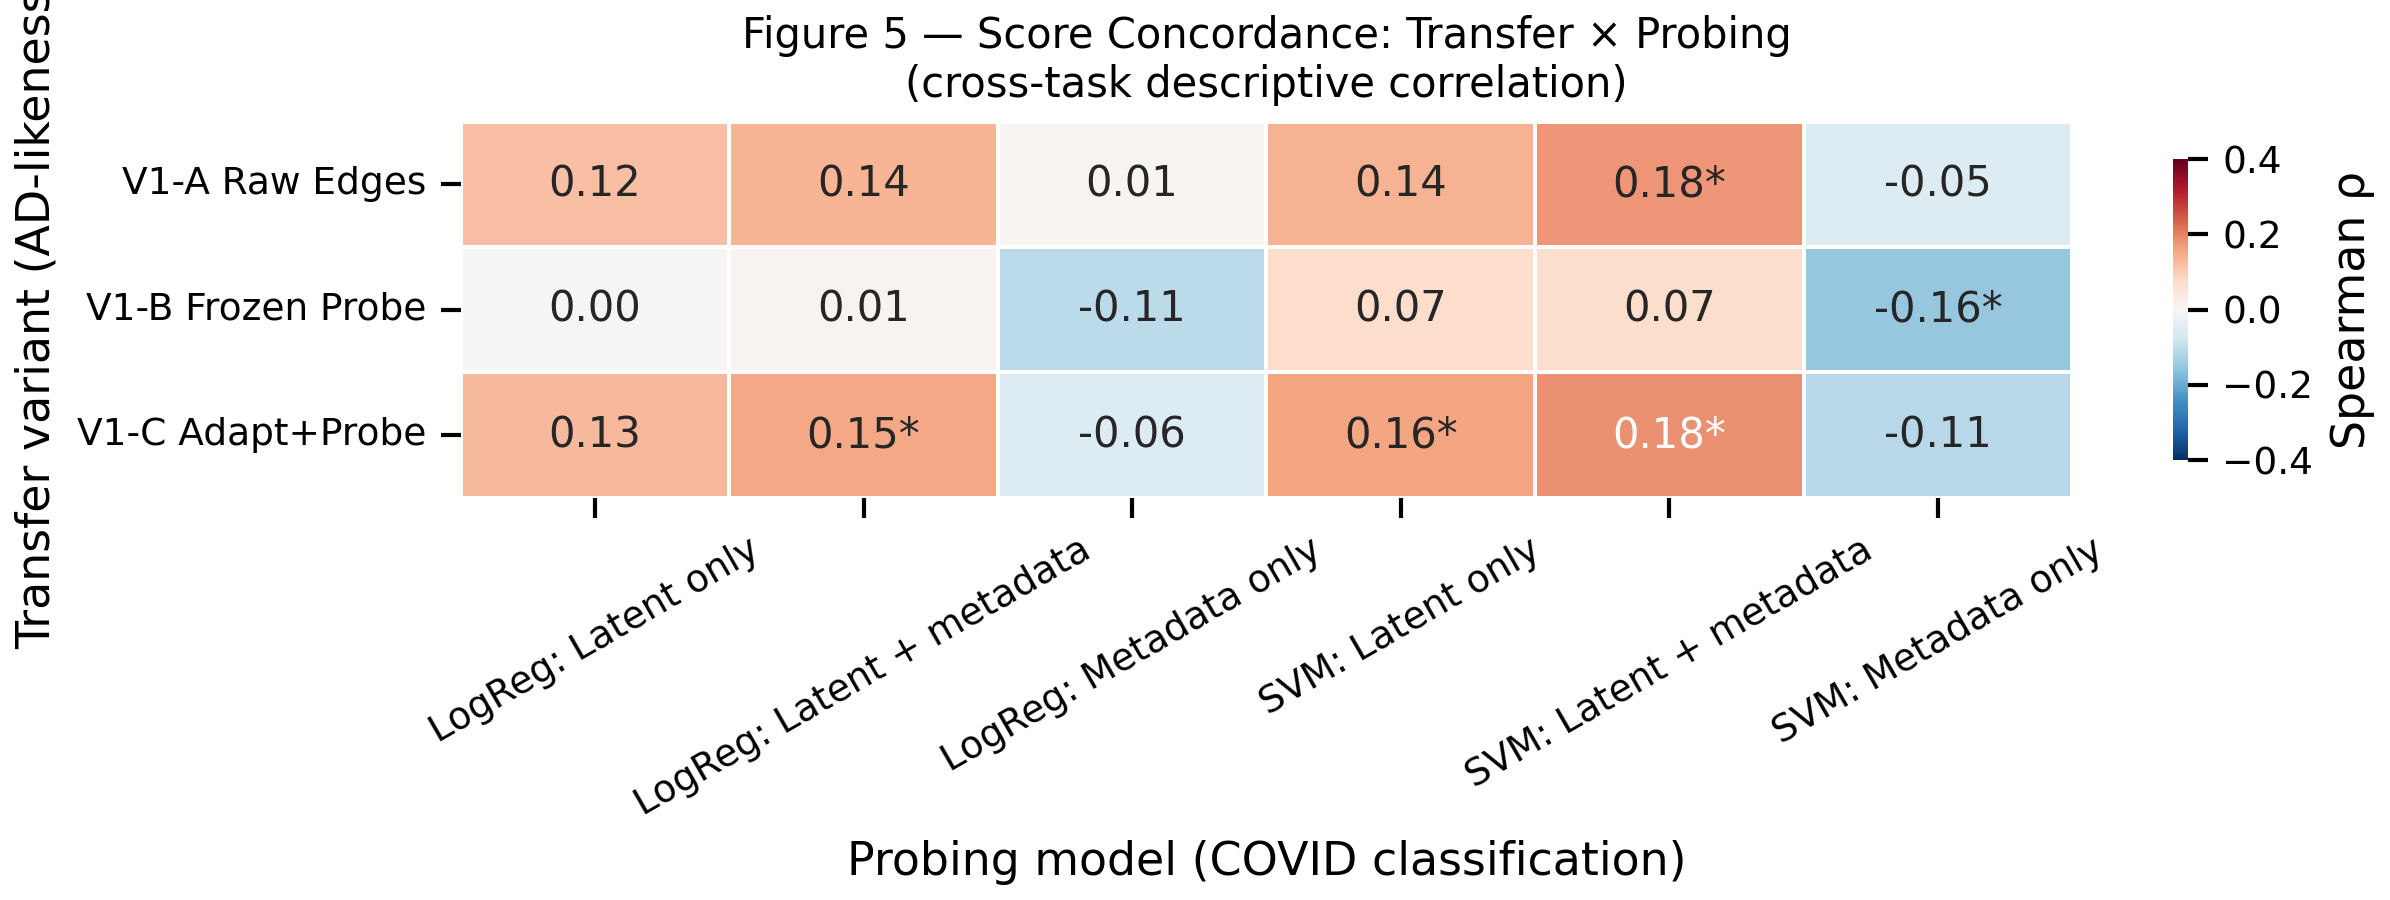

Stars: * p<0.05, ** p<0.01, *** p<0.001 (uncorrected)


In [9]:
# Pivot probing OOF to wide: one score column per (clf, family)
probing_pivot = oof_fusion.pivot_table(
    index="SubjectID",
    columns=["model_type", "feature_family"],
    values="y_score_fused",
)
probing_col_labels = [
    f"{CLF_LABELS[m]}: {FAMILY_LABELS[f]}" for m, f in probing_pivot.columns
]
probing_pivot.columns = probing_col_labels

# Transfer scores
scores_t = transfer.set_index("SubjectID")[score_cols]
scores_t.columns = [VARIANT_LABELS_FLAT[c] for c in score_cols]

combined = scores_t.join(probing_pivot, how="inner")

t_labels = scores_t.columns.tolist()
p_labels = probing_col_labels

# Spearman correlation matrix
corr = pd.DataFrame(np.nan, index=t_labels, columns=p_labels)
pval = pd.DataFrame(np.nan, index=t_labels, columns=p_labels)
for tc in t_labels:
    for pc in p_labels:
        r, p = stats.spearmanr(combined[tc], combined[pc])
        corr.loc[tc, pc] = r
        pval.loc[tc, pc] = p

# Annotation: ρ value + significance stars
annot = corr.copy().astype(str)
for tc in t_labels:
    for pc in p_labels:
        star = ""
        if pval.loc[tc, pc] < 0.001:
            star = "***"
        elif pval.loc[tc, pc] < 0.01:
            star = "**"
        elif pval.loc[tc, pc] < 0.05:
            star = "*"
        annot.loc[tc, pc] = f"{corr.loc[tc, pc]:.2f}{star}"

fig, ax = plt.subplots(figsize=(8.5, 3.2))
sns.heatmap(
    corr.astype(float), annot=annot, fmt="",
    cmap="RdBu_r", center=0, vmin=-0.40, vmax=0.40,
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Spearman ρ", "shrink": 0.8},
)
ax.set_title("Figure 5 — Score Concordance: Transfer × Probing\n(cross-task descriptive correlation)", fontsize=10)
ax.set_ylabel("Transfer variant (AD-likeness)")
ax.set_xlabel("Probing model (COVID classification)")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
save_figure(fig, FIG_DIR / "fig5_concordance_heatmap", formats=FIG_FORMATS)
plt.show()

print("Stars: * p<0.05, ** p<0.01, *** p<0.001 (uncorrected)")

## §9 — Transfer Score vs Clinical Correlate (MOCA)

The **MOCA** (Montreal Cognitive Assessment) is available for all 194
subjects and indexes cognitive burden — a dimension potentially aligned
with AD-likeness but orthogonal to the COVID binary label.

The left panel shows whether the AD-likeness score (V1-B) tracks MOCA;
the right panel shows whether the probing score tracks COVID status.
This comparison illustrates how one lens may capture a *biological
gradient* while the other targets *classification utility*.

Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/unified_transfer_probing_audit/Figures/fig6_moca_vs_probing.png
Saved: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/unified_transfer_probing_audit/Figures/fig6_moca_vs_probing.pdf


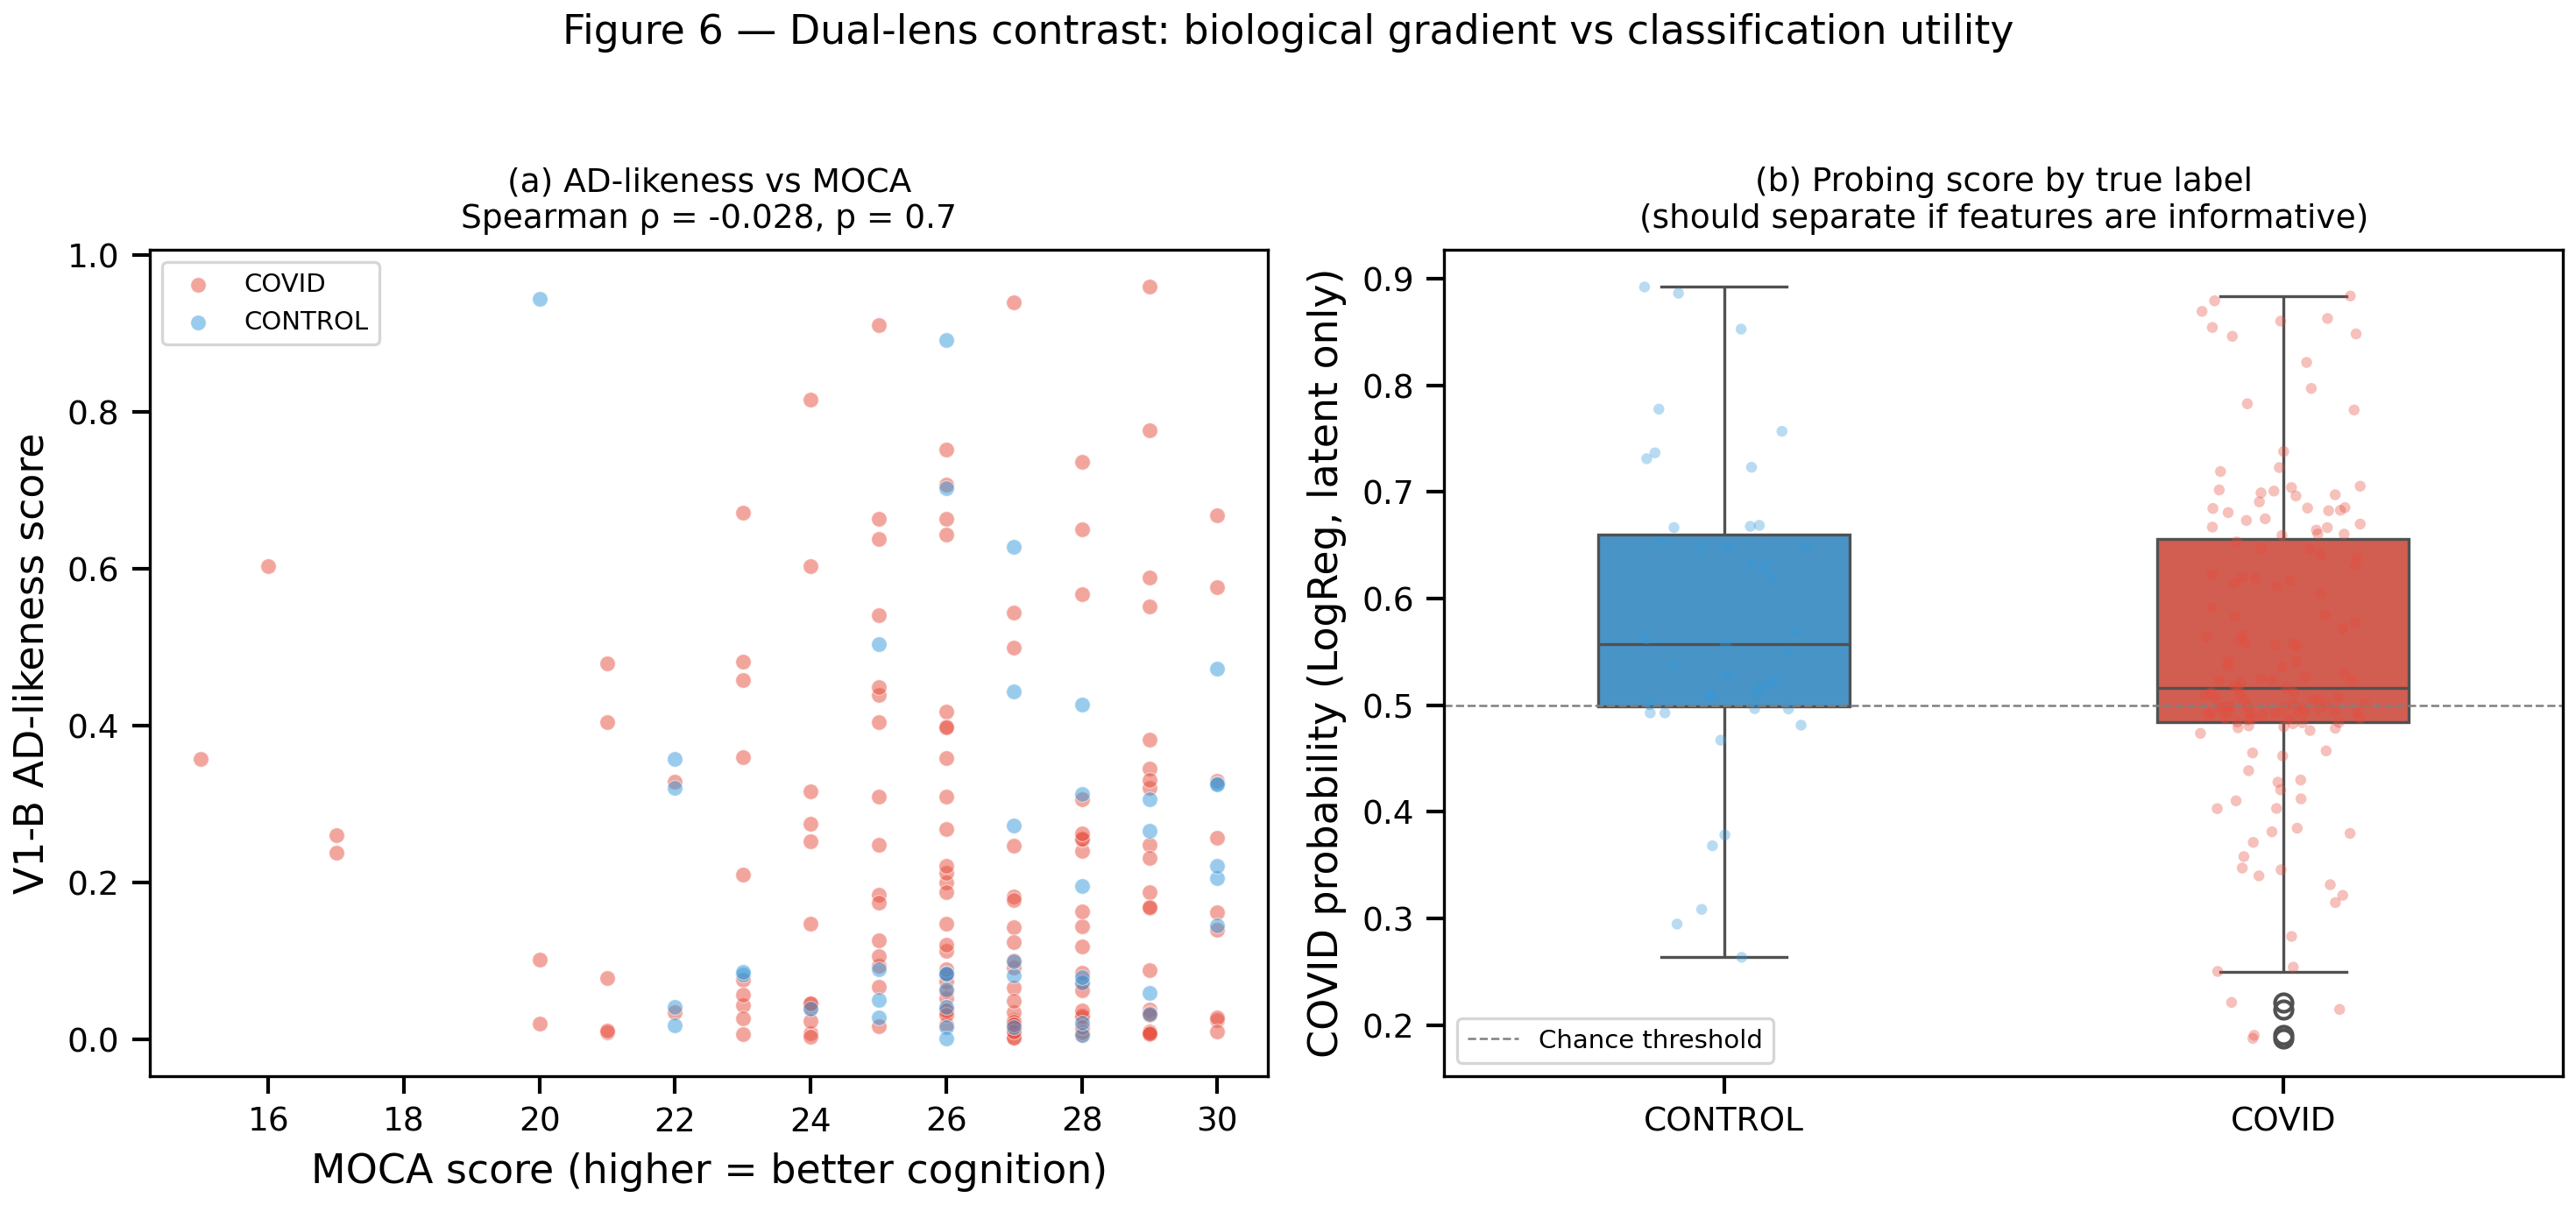

V1-B vs MOCA:  Spearman ρ = -0.0281  (p = 0.6973)
If ρ is non-trivial, the AD-likeness axis tracks cognitive burden
even though probing cannot classify COVID vs CONTROL.


In [10]:
# ── Figure 6: Transfer vs MOCA  |  Probing vs COVID label ──────────
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.5))

# --- Left panel: V1-B AD-likeness vs MOCA ---
ax = axes[0]
for grupo, color in GRUPO_PALETTE.items():
    mask = transfer["Grupo"] == grupo
    ax.scatter(
        transfer.loc[mask, "MOCA"],
        transfer.loc[mask, "v1b_y_score_mean"],
        c=color, label=grupo, alpha=0.5, s=18,
        edgecolors="white", linewidths=0.3,
    )
# Spearman over full sample
r_moca, p_moca = stats.spearmanr(transfer["MOCA"], transfer["v1b_y_score_mean"])
ax.set_xlabel("MOCA score (higher = better cognition)")
ax.set_ylabel("V1-B AD-likeness score")
ax.set_title(
    f"(a) AD-likeness vs MOCA\nSpearman ρ = {r_moca:.3f}, p = {p_moca:.2g}",
    fontsize=9,
)
ax.legend(fontsize=7, frameon=True)

# --- Right panel: probing score distribution by true COVID label ---
ax = axes[1]
probe_lat = oof_fusion.query(
    "model_type == 'logreg' and feature_family == 'latent_only'"
).copy()
probe_lat["Label"] = probe_lat["y_true"].map({0: "CONTROL", 1: "COVID"})
sns.boxplot(
    data=probe_lat, x="Label", y="y_score_fused",
    palette=GRUPO_PALETTE, ax=ax, width=0.45, linewidth=0.8,
)
sns.stripplot(
    data=probe_lat, x="Label", y="y_score_fused",
    palette=GRUPO_PALETTE, ax=ax, size=3, alpha=0.35, jitter=0.15,
)
ax.axhline(0.5, ls="--", lw=0.6, color="gray", label="Chance threshold")
ax.set_xlabel("")
ax.set_ylabel("COVID probability (LogReg, latent only)")
ax.set_title("(b) Probing score by true label\n(should separate if features are informative)", fontsize=9)
ax.legend(fontsize=7, frameon=True)

fig.suptitle("Figure 6 — Dual-lens contrast: biological gradient vs classification utility", y=1.03, fontsize=11)
fig.tight_layout()
save_figure(fig, FIG_DIR / "fig6_moca_vs_probing", formats=FIG_FORMATS)
plt.show()

print(f"V1-B vs MOCA:  Spearman ρ = {r_moca:.4f}  (p = {p_moca:.4g})")
print("If ρ is non-trivial, the AD-likeness axis tracks cognitive burden")
print("even though probing cannot classify COVID vs CONTROL.")

## §10 — Integrated Scientific Interpretation

### Summary of findings

| Aspect | Transfer analysis | Probing analysis |
|--------|-------------------|------------------|
| **Target** | AD vs CN (trained on ADNI) | COVID vs CONTROL (trained on COVID cohort) |
| **Feature source** | Same frozen β-VAE encoders | Same frozen β-VAE encoders |
| **Evaluation** | Apply ADNI classifier to COVID cohort (no CV) | 5-fold CV within COVID cohort |
| **Score semantics** | AD-likeness ∈ [0, 1] (phenotypic projection) | COVID probability / SVM decision score (classification utility) |
| **Group discrimination** | Grupo AUC ≈ 0.5 — AD-likeness does not align with COVID label | AUC ≈ 0.4–0.55 — below chance for latent features |
| **Implication** | COVID/CONTROL groups overlap on the AD phenotype axis | Latent features cannot separate COVID from CONTROL |

### The two lenses yield different — but compatible — conclusions

1. **Probing does not support COVID vs CONTROL discrimination.**
   All latent-based probing models achieve AUC ≤ 0.5, and even the
   metadata-only baseline (Age + Sex) barely reaches 0.55.  The β-VAE
   latent space, optimised for AD vs CN, does not encode features that
   enable supervised separation of COVID from CONTROL in this cohort.

2. **Transfer results are a biological/phenotypic projection, not a COVID classifier.**
   The transfer variants apply ADNI-derived classifiers to the COVID
   data to ask "how AD-like is each subject?"  The finding that
   Grupo ROC-AUC ≈ 0.5 means that COVID and CONTROL subjects are
   *equally distributed along the AD-likeness axis* — neither group
   preferentially resembles AD.  This is a meaningful biological result
   in its own right (post-COVID brain connectivity, at least at this
   resolution, does not systematically shift toward AD-like patterns),
   but it is *not a failure of the transfer analysis per se*.

3. **The two analyses are complementary and partially decoupled.**
   Subject-level correlations between transfer and probing scores
   (Figures 3, 5) are weak.  This is expected given the task mismatch
   (§7): the AD-likeness axis and the COVID-separability axis are
   largely orthogonal.  A strong transfer signal *could* coexist with
   poor probing (e.g., if AD-likeness tracked a subgroup effect not
   aligned with the binary COVID label), but in this cohort neither
   lens yields strong group separation.

### What these results do and do not rule out

| Statement | Supported? |
|-----------|------------|
| Frozen ADNI latent features can classify COVID vs CONTROL | ✗ — probing AUC ≤ 0.5 |
| COVID subjects look more AD-like than controls | ✗ — transfer Grupo AUC ≈ 0.5 |
| The β-VAE encoder is biologically uninformative | **Not tested** — the encoder works well on ADNI (AUC ≈ 0.77–0.81); it simply doesn't capture COVID-relevant variance |
| Post-COVID connectivity is indistinguishable from controls | **Suggestive but not definitive** — the analysis is limited to the AD-likeness lens and a small sample (n = 43 controls) |
| AD-likeness could track clinical gradients (MOCA, severity) | **Open** — see §9 for exploratory correlations |

### PR-AUC caveat
The 77.8% COVID prevalence means a random classifier achieves
PR-AUC ≈ 0.778.  All reported PR-AUC values are near or below this
baseline and should **not** be interpreted as evidence of predictive
ability.

### Conclusion

> **The ADNI-derived β-VAE representations do not support COVID vs
> CONTROL discrimination**, as shown by the probing analysis
> (AUC ≤ 0.5).  The transfer analysis reveals that COVID and CONTROL
> subjects are equally distributed along the AD-likeness axis
> (Grupo AUC ≈ 0.5), meaning post-COVID connectivity does not
> systematically resemble AD.  These are **complementary null findings
> on different questions** — poor probing does not invalidate the
> transfer lens, and vice-versa.  The two score axes are largely
> uncorrelated (Figures 3, 5), confirming that AD-likeness and
> COVID-separability represent distinct dimensions in the latent space.